# Custom Components Tutorial

`jaxqsofit` custom components are fully generic additive terms. This notebook shows how to build executable continuum and line extensions using user-defined functions.


## 1. Imports

The generic APIs are `make_custom_component(...)` for continuum-like additive terms and `make_custom_line_component(...)` for emission-line terms.


In [1]:
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

from jaxqsofit import (
    QSOFit,
    build_default_prior_config,
    make_custom_component,
    make_custom_line_component,
    make_template_component,
)
from jaxqsofit.model import _fe_template_component


## 2. Build A Small Synthetic Spectrum

This keeps the examples executable without relying on external downloads.


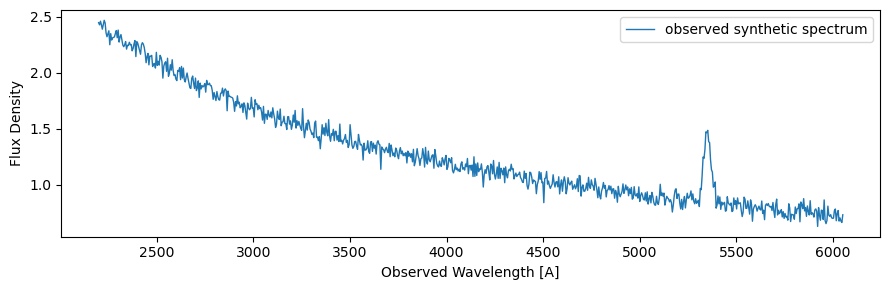

In [2]:
rng = np.random.default_rng(0)

z = 0.1
wave_rest = np.linspace(2000.0, 5500.0, 800)
lam_obs = wave_rest * (1.0 + z)

powerlaw = 1.5 * (wave_rest / 3000.0) ** (-1.2)
hbeta = 0.6 * np.exp(-0.5 * ((wave_rest - 4862.68) / 18.0) ** 2)
noise_sigma = 0.05
err = np.full_like(wave_rest, noise_sigma)
flux = powerlaw + hbeta + rng.normal(0.0, noise_sigma, size=wave_rest.size)

plt.figure(figsize=(9, 3))
plt.plot(lam_obs, flux, lw=1, label='observed synthetic spectrum')
plt.xlabel('Observed Wavelength [A]')
plt.ylabel('Flux Density')
plt.legend()
plt.tight_layout()


## 3. Generic Continuum Component

A custom continuum component is just a function `evaluate(wave, params, metadata)` plus a prior dictionary.


In [3]:
def gaussian_bump_component(wave, params, metadata):
    mu = metadata['mu']
    sigma = metadata['sigma']
    x = (wave - mu) / sigma
    return params['amp'] * jnp.exp(-0.5 * x**2)

custom_components = [
    make_custom_component(
        name='gaussian_bump',
        parameter_priors={
            'amp': {'dist': 'LogNormal', 'loc': np.log(0.02), 'scale': 0.5},
        },
        evaluate=gaussian_bump_component,
        metadata={'mu': 2800.0, 'sigma': 120.0},
    ),
]

prior_config = build_default_prior_config(flux)
custom_components[0]


CustomComponentSpec(name='gaussian_bump', parameter_priors={'amp': {'dist': 'LogNormal', 'loc': np.float64(-3.912023005428146), 'scale': 0.5}}, evaluate=<function gaussian_bump_component at 0x30b07bba0>, metadata={'mu': 2800.0, 'sigma': 120.0})

## 4. Additive Polynomial As A Normal Custom Component

There is no special polynomial helper. If you want one, write it as a regular custom component.


In [4]:
def additive_poly_component(wave, params, metadata):
    pivot = metadata['pivot']
    x = (wave - pivot) / pivot
    return params['c0'] + params['c1'] * x + params['c2'] * x**2

poly_component = make_custom_component(
    name='blue_excess',
    parameter_priors={
        'c0': {'dist': 'Normal', 'loc': 0.0, 'scale': 0.2 * np.nanmedian(np.abs(flux))},
        'c1': {'dist': 'Normal', 'loc': 0.0, 'scale': 0.05 * np.nanmedian(np.abs(flux))},
        'c2': {'dist': 'Normal', 'loc': 0.0, 'scale': 0.05 * np.nanmedian(np.abs(flux))},
    },
    evaluate=additive_poly_component,
    metadata={'pivot': 3000.0},
)

poly_component


CustomComponentSpec(name='blue_excess', parameter_priors={'c0': {'dist': 'Normal', 'loc': 0.0, 'scale': np.float64(0.23287113332133008)}, 'c1': {'dist': 'Normal', 'loc': 0.0, 'scale': np.float64(0.05821778333033252)}, 'c2': {'dist': 'Normal', 'loc': 0.0, 'scale': np.float64(0.05821778333033252)}}, evaluate=<function additive_poly_component at 0x30b07b380>, metadata={'pivot': 3000.0})

## 5. Template Convenience Wrapper

`make_template_component(...)` is still available for the common broadened-template case, but it is only convenience sugar around the generic API.


In [5]:
template_wave = np.linspace(2200.0, 3200.0, 300)
template_flux = np.exp(-0.5 * ((template_wave - 2700.0) / 140.0) ** 2)

template_component = make_template_component(
    'alt_feii',
    wave=template_wave,
    flux=template_flux,
    fit_fwhm=True,
    fit_shift=True,
)

template_component


CustomComponentSpec(name='alt_feii', parameter_priors={'norm': {'dist': 'LogNormal', 'loc': np.float64(-6.907755278982137), 'scale': 0.5}, 'fwhm': {'dist': 'LogNormal', 'loc': np.float64(8.006367567650246), 'scale': 0.3}, 'shift': {'dist': 'Normal', 'loc': 0.0, 'scale': 0.001}}, evaluate=<function template_component_evaluator at 0x17b9c1940>, metadata={'wave': array([2200.        , 2203.34448161, 2206.68896321, 2210.03344482,
       2213.37792642, 2216.72240803, 2220.06688963, 2223.41137124,
       2226.75585284, 2230.10033445, 2233.44481605, 2236.78929766,
       2240.13377926, 2243.47826087, 2246.82274247, 2250.16722408,
       2253.51170569, 2256.85618729, 2260.2006689 , 2263.5451505 ,
       2266.88963211, 2270.23411371, 2273.57859532, 2276.92307692,
       2280.26755853, 2283.61204013, 2286.95652174, 2290.30100334,
       2293.64548495, 2296.98996656, 2300.33444816, 2303.67892977,
       2307.02341137, 2310.36789298, 2313.71237458, 2317.05685619,
       2320.40133779, 2323.7458194

## 6. Fully User-Controlled Template Physics

If you want to own all the broadening or shifting behavior yourself, put that directly in the evaluator.


In [6]:
def my_feii_component(wave, params, metadata):
    return _fe_template_component(
        wave=wave,
        wave_template=metadata['wave_template'],
        flux_template=metadata['flux_template'],
        norm=params['norm'],
        fwhm_kms=params['fwhm_kms'],
        shift_frac=params['shift_frac'],
        base_fwhm_kms=metadata['base_fwhm_kms'],
    )

manual_template_component = make_custom_component(
    name='manual_alt_feii',
    parameter_priors={
        'norm': {'dist': 'LogNormal', 'loc': np.log(0.02), 'scale': 0.6},
        'fwhm_kms': {'dist': 'LogNormal', 'loc': np.log(2500.0), 'scale': 0.3},
        'shift_frac': {'dist': 'Normal', 'loc': 0.0, 'scale': 1e-3},
    },
    evaluate=my_feii_component,
    metadata={
        'wave_template': template_wave,
        'flux_template': template_flux,
        'base_fwhm_kms': 900.0,
    },
)

manual_template_component


CustomComponentSpec(name='manual_alt_feii', parameter_priors={'norm': {'dist': 'LogNormal', 'loc': np.float64(-3.912023005428146), 'scale': 0.6}, 'fwhm_kms': {'dist': 'LogNormal', 'loc': np.float64(7.824046010856292), 'scale': 0.3}, 'shift_frac': {'dist': 'Normal', 'loc': 0.0, 'scale': 0.001}}, evaluate=<function my_feii_component at 0x30b07bce0>, metadata={'wave_template': array([2200.        , 2203.34448161, 2206.68896321, 2210.03344482,
       2213.37792642, 2216.72240803, 2220.06688963, 2223.41137124,
       2226.75585284, 2230.10033445, 2233.44481605, 2236.78929766,
       2240.13377926, 2243.47826087, 2246.82274247, 2250.16722408,
       2253.51170569, 2256.85618729, 2260.2006689 , 2263.5451505 ,
       2266.88963211, 2270.23411371, 2273.57859532, 2276.92307692,
       2280.26755853, 2283.61204013, 2286.95652174, 2290.30100334,
       2293.64548495, 2296.98996656, 2300.33444816, 2303.67892977,
       2307.02341137, 2310.36789298, 2313.71237458, 2317.05685619,
       2320.40133779

## 7. Custom Line Components

Custom emission-line components are attached to the line model and tagged as either `broad` or `narrow`.


In [7]:
def exponential_line_profile(wave, params, metadata):
    center = metadata['center']
    tau = params['tau']
    amp = params['amp']
    x = jnp.abs(wave - center) / tau
    return amp * jnp.exp(-x)

custom_line_components = [
    make_custom_line_component(
        name='exp_hbeta_wing',
        parameter_priors={
            'amp': {'dist': 'LogNormal', 'loc': np.log(0.02), 'scale': 0.5},
            'tau': {'dist': 'LogNormal', 'loc': np.log(15.0), 'scale': 0.3},
        },
        evaluate=exponential_line_profile,
        line_kind='broad',
        metadata={'center': 4862.68},
    ),
]

custom_line_components[0]


CustomLineComponentSpec(name='exp_hbeta_wing', parameter_priors={'amp': {'dist': 'LogNormal', 'loc': np.float64(-3.912023005428146), 'scale': 0.5}, 'tau': {'dist': 'LogNormal', 'loc': np.float64(2.70805020110221), 'scale': 0.3}}, evaluate=<function exponential_line_profile at 0x30b07be20>, line_kind='broad', metadata={'center': 4862.68})

## 8. Simulate A Fake Exponential Wing And Fit It

Here we inject a broad exponential wing near H$\\beta$ into the synthetic spectrum, then fit that spectrum with a matching `custom_line_component`.


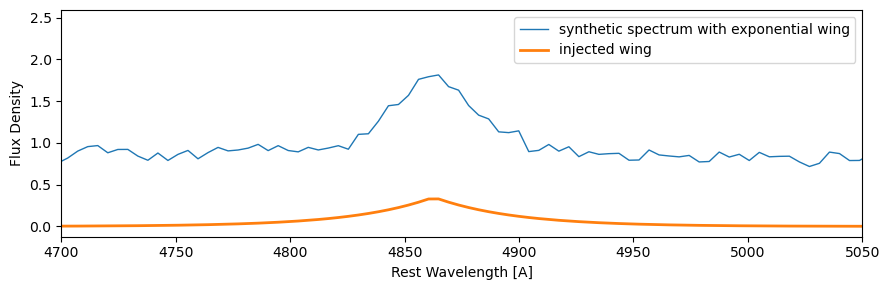

In [8]:
wing_amp_true = 0.35
wing_tau_true = 35.0
wing_flux = np.asarray(
    exponential_line_profile(
        wave_rest,
        params={'amp': wing_amp_true, 'tau': wing_tau_true},
        metadata={'center': 4862.68},
    )
)

flux_with_wing = flux + wing_flux

plt.figure(figsize=(9, 3))
plt.plot(wave_rest, flux_with_wing, lw=1, label='synthetic spectrum with exponential wing')
plt.plot(wave_rest, wing_flux, lw=2, label='injected wing')
plt.xlim(4700, 5050)
plt.xlabel('Rest Wavelength [A]')
plt.ylabel('Flux Density')
plt.legend()
plt.tight_layout()


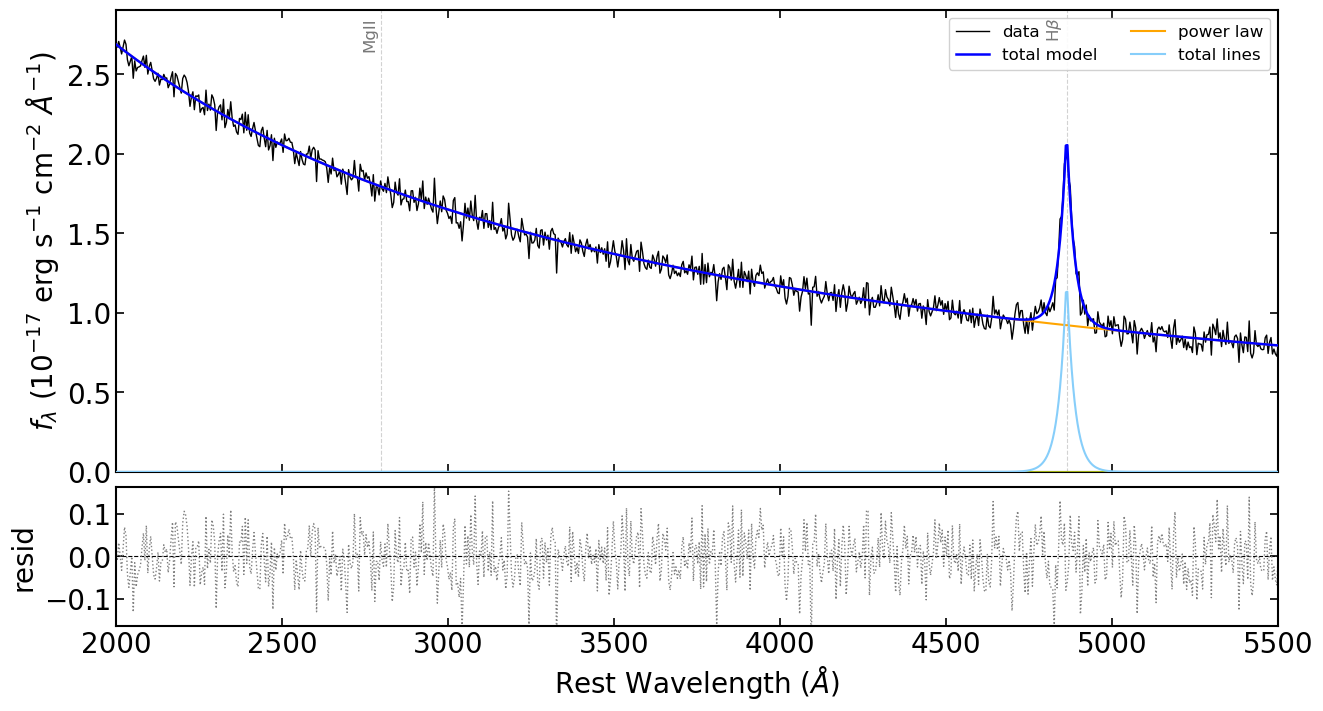

In [12]:
wing_prior_config = build_default_prior_config(flux_with_wing)
wing_prior_config['custom_line_exp_hbeta_wing_amp'] = {
    'dist': 'LogNormal',
    'loc': np.log(0.2),
    'scale': 0.7,
}
wing_prior_config['custom_line_exp_hbeta_wing_tau'] = {
    'dist': 'LogNormal',
    'loc': np.log(25.0),
    'scale': 0.5,
}

q_wing = QSOFit(lam=lam_obs, flux=flux_with_wing, err=err, z=z)
q_wing.fit(
    deredden=False,
    prior_config=wing_prior_config,
    custom_line_components=custom_line_components,
    fit_fe=False,
    fit_bc=False,
    fit_poly=False,
    fit_lines=False,
    fit_method='optax',
    decompose_host=False,
    optax_steps=2000,
    save_result=False,
    plot_fig=True,
    save_fig=False,
    verbose=False,
)


## 9. Prior Naming Convention

Each local parameter gets expanded into a global prior/sample key:

- continuum component `gaussian_bump`, parameter `amp` -> `custom_gaussian_bump_amp`
- line component `exp_hbeta_wing`, parameter `tau` -> `custom_line_exp_hbeta_wing_tau`


## 10. Save/Load Note

If you want `QSOFit.load_from_samples(...)` to restore custom components cleanly, define evaluators as importable top-level Python functions.

Avoid lambdas, nested functions, and local closures for production use.
